<a href="https://colab.research.google.com/github/Drakey-504/synthetic-phishing-generation-and-detection/blob/main/02_Baseline_Logistic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Loading the data
url_emails_cleaned = 'https://raw.githubusercontent.com/Drakey-504/synthetic-phishing-generation-and-detection/main/data/processed/emails_clean.csv'
url_synthetic_phishing = 'https://raw.githubusercontent.com/Drakey-504/synthetic-phishing-generation-and-detection/main/data/processed/synthetic_phishing.csv'

emails_clean = pd.read_csv(url_emails_cleaned)
synthetic_phishing = pd.read_csv(url_synthetic_phishing)

print(emails_clean.columns.tolist())
print(synthetic_phishing.columns.tolist())

# labeled phishing or legitimate
# emails_clean
# synthetic_phishing.head()




['id', 'source', 'subject', 'text', 'label', 'split']
['id', 'method', 'sophistication', 'scenario', 'prompt_id', 'model', 'temperature', 'subject', 'text', 'label']


In [2]:
# Encoding string labels to binary
# Label: 0 = legitimate, 1 = phishing

TEXT_COL = 'text'

label_map = {'legitimate': 0, 'phishing': 1}
synthetic_phishing['label'] = synthetic_phishing['label'].map(label_map)
emails_clean['label'] = emails_clean['label'].map(label_map)

combined = pd.concat([synthetic_phishing, emails_clean], ignore_index=True)
combined = combined[[TEXT_COL, 'label']].dropna()
print(combined['label'].value_counts())
combined


label
0    8398
1    5295
Name: count, dtype: int64


,text,label
0,"Dear Emily Chen,\n\nWe have temporarily suspen...",1
1,"Dear Julia Rodriguez,\n\nWe've temporarily sus...",1
2,"Dear Emily Wilson,\n\nWe're writing to inform ...",1
3,"Dear Rachel Thompson,\n\nWe have temporarily s...",1
4,"Dear Rachel Davis,\n\nWe've detected some unus...",1
...,...,...
13688,http://news.bbc.co.uk/1/hi/england/2515127.stm...,0
13689,"> >-- be careful when using this one.) Also, t...",0
13690,">>>>> ""SM"" == Skip Montanaro writes:\n\nJeremy...",0
13691,"So then, ""Mark Hammond"" is all like:\n\n> So, ...",0


In [3]:
# Preprocessing

import re
from sklearn.model_selection import train_test_split

# reducing noise for logistic classifier
def clean_text(text):
  text = str(text).lower()

  # normalising URLs
  text = re.sub(r'http\S+|www\S+', 'URL', text)

  # normalising emails
  text = re.sub(r'\S+@\S+', 'EMAIL', text)

  #removing whitespace
  text = re.sub(r'\s+', ' ', text).strip()

  return text

combined['clean_text'] = combined[TEXT_COL].apply(clean_text)

# train test split
X = combined['clean_text']
y = combined['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

Train size: 10954
Test size: 2739


In [4]:
# tf-idf vectorisation
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,    # vocab limit
    ngram_range = (1,2),  #unigrams & bigrams
    sublinear_tf=True,    # log scale tf
    min_df=2,
    )

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

# Logistic Regression Model

In [5]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

lr_model.fit(X_train_vec, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000)

              precision    recall  f1-score   support

  Legitimate       0.99      1.00      0.99      1654
    Phishing       1.00      0.98      0.99      1085

    accuracy                           0.99      2739
   macro avg       0.99      0.99      0.99      2739
weighted avg       0.99      0.99      0.99      2739

ROC-AUC: 0.9994

Synthetic phishing evasion rate: 0.99%


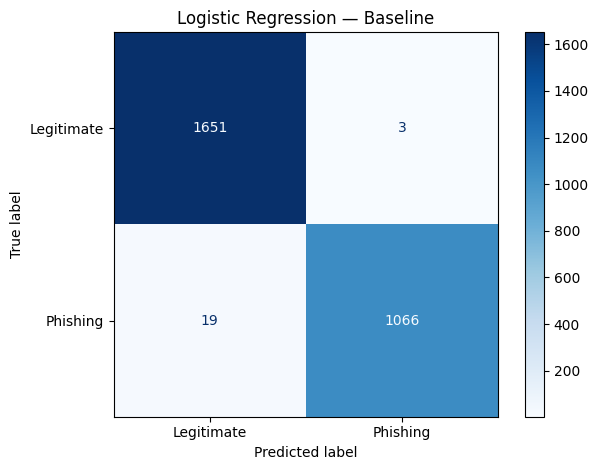

In [7]:
# LR Model Evaluation & Evasion Rate

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

y_pred = lr_model.predict(X_test_vec)
y_proba = lr_model.predict_proba(X_test_vec)[:, 1]

print(classification_report(y_test, y_pred,
      target_names=['Legitimate', 'Phishing']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")



# evasion rate for synthetic phishing
synthetic_mask = combined.loc[X_test.index, TEXT_COL].isin(
    synthetic_phishing[TEXT_COL]
)

if synthetic_mask.any():
    synth_preds = y_pred[synthetic_mask]
    evasion_rate = (synth_preds == 0).mean()   # predicted as being a legitimate email
    print(f"\nSynthetic phishing evasion rate: {evasion_rate:.2%}")


ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=['Legitimate', 'Phishing']
).plot(cmap='Blues')
plt.title('Logistic Regression — Baseline')
plt.tight_layout()
plt.show()